In [ ]:
import numpy as np
import pandas as pd 
from pathlib import Path

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

from sklearn.metrics import r2_score
from scipy.stats import spearmanr

In [6]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '17_humenv_cat_reg-2025-05-19_11-35-preds' / 'predictions.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
predictions = np.exp(predictions) - 1

predictions_tb = predictions.sum(axis=1)
predictions_sr = (predictions > 0).sum(axis=1)
predictions_prev = (predictions > 0).sum(axis=0)

In [18]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
df = pd.read_csv(p, index_col='survey_id',
                      usecols = ['survey_id', 'subset'] + list(predictions.columns))
targets = df.loc[df['subset'] == 'test', predictions.columns]

# Test dataset summary
targets_tb = targets.sum(axis=1)
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

## Calculate R2 by species

In [ ]:
r2s = {}

for s in predictions.columns:
    groundtruth = targets[s]
    preds = predictions[s]

    r2s[s] = r2_score(np.log(1+groundtruth), np.log(1+preds))
    #r2s[s] = spearmanr(groundtruth, preds)


r2s = pd.Series(r2s)

In [20]:
df = pd.concat([targets_prev, r2s], axis = 1)
df.columns = ['occurrences', 'r2']
df['species'] = df.index
df['r2'].describe()


count    10.000000
mean      0.257923
std       0.415379
min      -0.311971
25%      -0.000913
50%       0.222937
75%       0.597631
max       0.834863
Name: r2, dtype: float64

In [21]:
common = df[df['occurrences'] >= 3]
fig = px.scatter(common, x="occurrences", y="r2", hover_data = "species")
fig.show()

## Species richness

<Axes: xlabel='None', ylabel='None'>

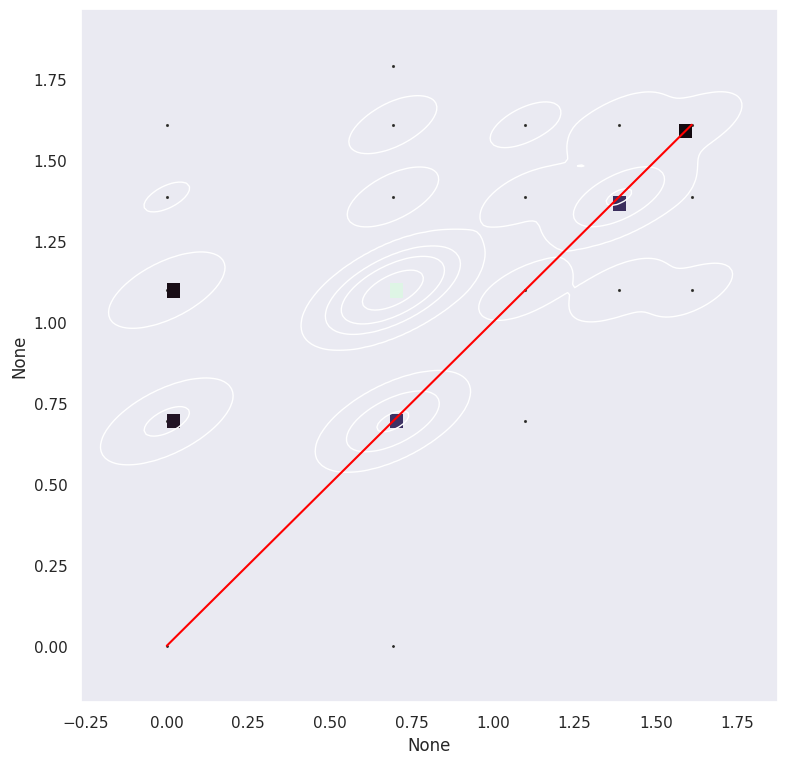

In [22]:
x, y = np.log(1+targets_sr), np.log(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')